# Single-point history on a circular domain — ETAS vs analytical vs thinning

Copy of `single_point_history_circular_domain.ipynb` with **grid / Voronoi point-process simulations removed**.

Compare three first-event forecasts using a **simplified temporal kernel** `g(t) = (t - t_h + c)^{-(1+ω)}` (no exponential `τ` decay) for the analytical curve and Ogata thinning. Classic ETAS catalog continuation still uses the full production kernel.

Toggle `USE_SIMPLE_G = False` in the helpers cell to revert to the full ETAS `g(t)` for A and C.

In [1]:
from typing import TypedDict
import datetime as dt

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyproj
import scipy
import shapely
import etas.mc_b_est as mc_b_est
import etas.utility_functions as utility_functions
import etas.simulation as simulation
from etas.inversion import polygon_surface
from matplotlib import colors
from matplotlib.path import Path as MplPath
from shapely.geometry import Point, Polygon
from shapely.ops import transform
from tqdm.auto import tqdm



%matplotlib inline


2026-06-22 13:34:49.510115: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-22 13:34:49.544533: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-22 13:34:49.544573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-22 13:34:49.545862: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-22 13:34:49.551968: I tensorflow/core/platform/cpu_feature_guar

2026-06-22 13:34:51,691 - DEBUG - Loaded backend inline version unknown.


In [2]:
EARTH_RADIUS_KM = 6.3781e3


def _swap_xy(x, y):
    return y, x


def unreg_gamma(a, x):
    return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)


In [3]:
# Spatial quadrature resolution for A_h (used only by classic ETAS polygon helpers if needed).
A_H_RESOLUTION = 40

# Simple temporal kernel: power law only (no exponential decay in tau).
# Full ETAS uses g_full = exp(-dt/tau) / (dt + c)^(1+omega).
USE_SIMPLE_G = True


class History(TypedDict):
    m: float
    x: float
    y: float
    t: float


class EtasParams(TypedDict):
    mu: float
    k0: float
    a: float
    m_c: float
    d: float
    gamma: float
    rho: float
    c: float
    tau: float
    omega: float


def a_h(x: float, y: float, H: History, params: EtasParams):
    """Spatial triggering kernel at (x, y) = (lon, lat) from history event H."""
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        y, x, H["y"], H["x"]
    )
    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    return K / (dist_sq_km2 + C) ** (1 + params["rho"])


def A_h_of_m_circ(m: float, params: EtasParams, R: float = 2) -> float:
    K = params["k0"] * np.exp(params["a"] * (m - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (m - params["m_c"]))
    return K * (np.pi / params["rho"]) * (
        1 / C ** params["rho"] - 1 / ((R**2 + C) ** params["rho"])
    )


def polygon_area(polygon: Polygon) -> float:
    geod = pyproj.Geod(ellps="WGS84")
    area_m2, _ = geod.geometry_area_perimeter(polygon)
    return abs(area_m2) / 1e6


def g_full(t: float, H: History, params: EtasParams):
    dt = t - H["t"]
    return np.exp(-dt / params["tau"]) / (dt + params["c"]) ** (1 + params["omega"])


def g_simple(t: float, H: History, params: EtasParams):
    dt = t - H["t"]
    return 1.0 / (dt + params["c"]) ** (1 + params["omega"])


def g(t: float, H: History, params: EtasParams):
    return g_simple(t, H, params) if USE_SIMPLE_G else g_full(t, H, params)


def triggering_integral(t_prime: float, t: float, H: History, params: EtasParams) -> float:
    """Integral of g(s) ds from t to t_prime (simple power-law g)."""
    dt0 = max(t - H["t"], 0.0)
    dt1 = t_prime - H["t"]
    c = params["c"]
    p = 1.0 + params["omega"]
    if abs(p - 1.0) < 1e-12:
        return np.log((c + dt1) / (c + dt0))
    return ((c + dt0) ** (1.0 - p) - (c + dt1) ** (1.0 - p)) / (p - 1.0)


def triggering_integral_full(t_prime: float, t: float, H: History, params: EtasParams) -> float:
    t_h = H["t"]
    gamma_diff = (
        unreg_gamma(-params["omega"], (params["c"] + t_prime - t_h) / params["tau"])
        - unreg_gamma(-params["omega"], (params["c"] + t - t_h) / params["tau"])
    )
    const_multiplier = np.exp(params["c"] / params["tau"]) / (params["tau"] ** (-params["omega"]))
    return const_multiplier * gamma_diff


def integrated_triggering(t_prime: float, t: float, H: History, params: EtasParams) -> float:
    if USE_SIMPLE_G:
        return triggering_integral(t_prime, t, H, params)
    return triggering_integral_full(t_prime, t, H, params)


def etas_rate_at_xy(x, y, t, H: History, params: EtasParams):
    return params["mu"] + a_h(x, y, H, params) * g(t, H, params)


def etas_rate_space_integrated(t, area_km2, R, H: History, params: EtasParams):
    return params["mu"] * area_km2 + A_h_of_m_circ(H["m"], params, R=R) * g(t, H, params)


def log_rhs_region(t_prime: float, t: float, H: History, params: EtasParams) -> float:
    """Log survival probability for the circular study region."""
    background = -np.pi * CIRC_RADIUS**2 * params["mu"] * (t_prime - t)
    triggering = -A_h_of_m_circ(H["m"], params, R=CIRC_RADIUS) * integrated_triggering(
        t_prime, t, H, params
    )
    return background + triggering


In [4]:
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
    "m_c": 3.5,
}

for key in list(THETA_0.keys()):
    if key.startswith('log10_'):
        xx = key.replace('log10_', '')
        if xx not in THETA_0:
            THETA_0[xx] = 10 ** THETA_0[key]


THETA_0


{'log10_mu': -5.8,
 'log10_k0': -2.6,
 'a': 1.8,
 'log10_c': -2.5,
 'omega': -0.02,
 'log10_tau': 3.5,
 'log10_d': -0.85,
 'gamma': 1.3,
 'rho': 0.66,
 'm_c': 3.5,
 'mu': 1.584893192461114e-06,
 'k0': 0.0025118864315095794,
 'c': 0.0031622776601683794,
 'tau': 3162.2776601683795,
 'd': 0.14125375446227545}

In [5]:
history_event_time = "2006-12-29 00:00:00"
history_event_magnitude = 6.5
history_event_x = -120
history_event_y = 38

history_dict = {
    "m": history_event_magnitude,
    "x": history_event_x,
    "y": history_event_y,
    "t": (pd.to_datetime(history_event_time) - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"),
}


### Define domain area

2026-06-22 13:34:51,729 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-22 13:34:51,729 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:51,730 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:51,730 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

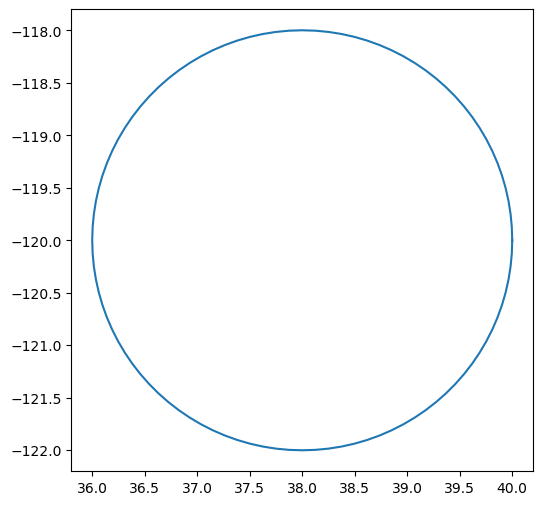

In [6]:

def regular_polygon(cx, cy, radius, n_sides):
    angles = np.linspace(0, 2 * np.pi, num=n_sides, endpoint=False)
    coords = [(cx + radius * np.cos(a), cy + radius * np.sin(a)) for a in angles]
    coords.append(coords[0])  # Ensure closure
    return Polygon(coords)

CIRCLE_RESOLUTION = 100  # Control the resolution (more sides = smoother)
CIRC_RADIUS = 2
circle = regular_polygon(history_event_y, history_event_x, CIRC_RADIUS, CIRCLE_RESOLUTION)

fig, ax = plt.subplots(figsize=(6, 6))
x_circ, y_circ = circle.exterior.xy
ax.plot(x_circ, y_circ, label="Maximum Inscribed Circle")
ax.set_aspect('equal')
plt.show()



In [7]:
# Study region is the inscribed circle defined above.
polygon = circle


### Probability of next event in the circular region


2026-06-22 13:34:52,075 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2026-06-22 13:34:52,076 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:52,076 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:52,076 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

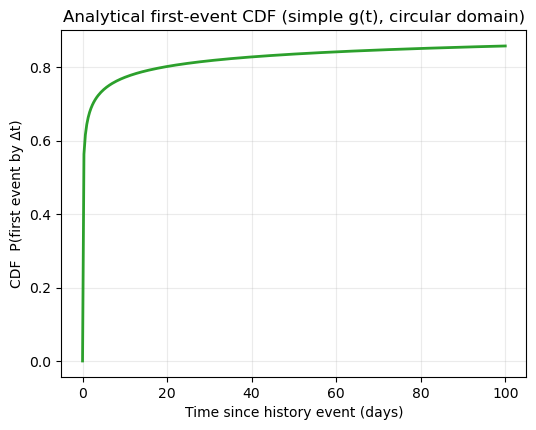

In [8]:
history_t_days = float(history_dict["t"])
t_prime_vec = np.linspace(0, 100, 300) + history_t_days

S_vec = np.exp(log_rhs_region(t_prime_vec, history_t_days, history_dict, THETA_0))
P_vec = 1.0 - S_vec

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_vec - history_t_days, P_vec, color="tab:green", linewidth=2)
ax.set_xlabel("Time since history event (days)")
ax.set_ylabel("CDF  P(first event by Δt)")
ax.set_title("Analytical first-event CDF (simple g(t), circular domain)")
ax.grid(True, alpha=0.25)
plt.show()


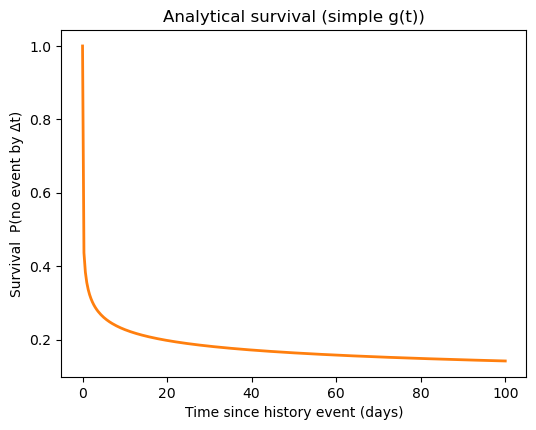

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_vec - history_t_days, S_vec, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since history event (days)")
ax.set_ylabel("Survival  P(no event by Δt)")
ax.set_title("Analytical survival (simple g(t))")
plt.show()


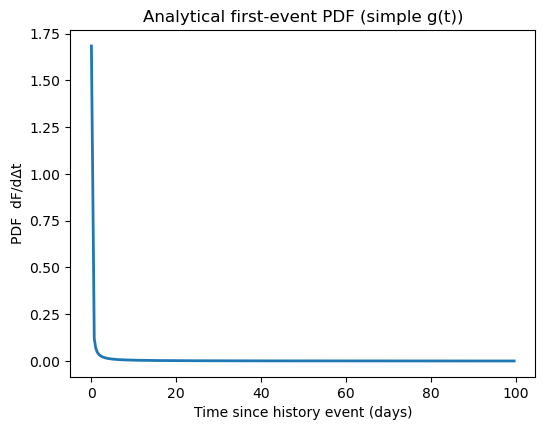

In [10]:
dt_step = t_prime_vec[1] - t_prime_vec[0]
pdf = np.clip(np.gradient(P_vec, dt_step), 0.0, None)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_vec[:-1] - history_t_days, pdf[:-1], color="tab:blue", linewidth=2)
ax.set_xlabel("Time since history event (days)")
ax.set_ylabel("PDF  dF/dΔt")
ax.set_title("Analytical first-event PDF (simple g(t))")
plt.show()


## Catalog continuation forecast

Run classic ETAS catalog continuation (`simulate_catalog_continuation`) from forecast start time **T**, using only the single history event above as auxiliary catalog. Each recreation keeps the **first forecast event** after **T** (extending the forecast window if needed).

In [11]:
# --- forecast settings (edit these) ---
FORECAST_START = history_event_time  # time T: forecast window starts here
N_RECREATIONS = 1000
N_FORECAST_EVENTS = 1  # keep the first event after T in each recreation
SEED_START = 0

# initial forecast window; extended automatically until N_FORECAST_EVENTS are found
INITIAL_FORECAST_DAYS = 30
MAX_FORECAST_DAYS = 3650
FORECAST_GROWTH_FACTOR = 2.0

# magnitude distribution (Gutenberg–Richter b=1 => beta = ln(10))
BETA_MAIN = np.log(10)
MC = THETA_0["m_c"]

from pathlib import Path
from typing import Optional

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history_circular_domain_compare"

# --- persistence ---
FORCE_RECREATE_RECREATIONS = False
SAVE_RECREATIONS_OUTPUT = True
SAVED_FORECAST_RECREATIONS_PATH = None


def forecast_recreations_path(n_recreations=None, seed_start=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    seed = SEED_START if seed_start is None else int(seed_start)
    return RECREATIONS_OUTPUT_DIR / f"forecast_recreations_n{n}_seed{seed}.csv"


def _resolve_saved_csv(explicit_path, canonical_path: Path) -> Optional[Path]:
    if explicit_path is not None:
        path = Path(explicit_path)
        if not path.is_file():
            raise FileNotFoundError(f"Saved recreations not found: {path}")
        if path.resolve() != canonical_path.resolve():
            print(
                f"Explicit path {path.name} does not match current settings "
                f"({canonical_path.name}); re-simulating."
            )
            return None
        return path
    if canonical_path.is_file():
        return canonical_path
    return None


def _note_stale_saved_csvs(glob_pattern: str, canonical_path: Path) -> None:
    if not RECREATIONS_OUTPUT_DIR.is_dir():
        return
    stale = sorted(
        RECREATIONS_OUTPUT_DIR.glob(glob_pattern),
        key=lambda p: p.name,
    )
    stale = [p for p in stale if p.resolve() != canonical_path.resolve()]
    if stale:
        names = ", ".join(p.name for p in stale[:5])
        suffix = " ..." if len(stale) > 5 else ""
        print(
            f"Note: found {len(stale)} saved CSV(s) with other parameters "
            f"({names}{suffix}); need {canonical_path.name} for current settings."
        )


In [12]:
import datetime

# ETAS parameters in the log10 form expected by simulate_catalog_continuation
theta = {
    key: THETA_0[key]
    for key in [
        "log10_mu",
        "log10_k0",
        "a",
        "log10_c",
        "omega",
        "log10_tau",
        "log10_d",
        "gamma",
        "rho",
    ]
}


def _to_naive_utc(ts):
    t = pd.to_datetime(ts, utc=True)
    return t.tz_convert(None)


def simulate_single_event_recreations(
    auxiliary_catalog,
    *,
    auxiliary_start,
    forecast_start,
    polygon,
    theta,
    mc,
    beta_main,
    n_events,
    n_recreations,
    seed_start,
    initial_forecast_days=30,
    max_forecast_days=3650,
    growth_factor=2.0,
):
    """Call simulate_catalog_continuation; keep first n_events after forecast_start."""
    aux_start = _to_naive_utc(auxiliary_start)
    f_start = _to_naive_utc(forecast_start)

    aux = auxiliary_catalog.copy()
    aux["time"] = pd.to_datetime(aux["time"], utc=True).dt.tz_convert(None)

    records = []
    seeds = range(seed_start, seed_start + n_recreations)
    for i, seed in enumerate(
        tqdm(seeds, total=n_recreations, desc="Recreations", unit="run")
    ):
        np.random.seed(int(seed))

        forecast_days = float(initial_forecast_days)
        chosen = None
        while forecast_days <= float(max_forecast_days):
            sim_end = f_start + datetime.timedelta(days=forecast_days)

            cont = simulation.simulate_catalog_continuation(
                auxiliary_catalog=aux,
                auxiliary_start=aux_start,
                auxiliary_end=f_start,
                polygon=polygon,
                simulation_end=sim_end,
                parameters=dict(theta),
                mc=float(mc),
                beta_main=beta_main,
                filter_polygon=False,
                magnitude_generator=mc_b_est.simulate_magnitudes,
            )

            cont = cont.copy()
            cont["time"] = pd.to_datetime(cont["time"], utc=True).dt.tz_convert(None)

            forecast_events = cont.loc[cont["time"] > f_start].sort_values("time")
            forecast_events = forecast_events.head(int(n_events))

            if len(forecast_events) >= int(n_events):
                chosen = forecast_events
                break

            forecast_days *= float(growth_factor)

        if chosen is None:
            raise RuntimeError(
                f"Recreation {i} (seed={seed}) did not reach {n_events} event(s) "
                f"within {max_forecast_days} forecast days."
            )

        chosen = chosen[["time", "latitude", "longitude", "magnitude"]].copy()
        chosen["recreation"] = i
        chosen["seed"] = int(seed)
        chosen["event_idx"] = np.arange(len(chosen), dtype=int)
        records.append(chosen)

    if not records:
        return pd.DataFrame(
            columns=[
                "time",
                "latitude",
                "longitude",
                "magnitude",
                "recreation",
                "seed",
                "event_idx",
            ]
        )
    return pd.concat(records, ignore_index=True)


auxiliary_catalog = pd.DataFrame(
    {
        "time": [_to_naive_utc(history_event_time)],
        "latitude": [history_event_y],
        "longitude": [history_event_x],
        "magnitude": [history_event_magnitude],
        "xi_plus_1": [1.0],
    }
)
auxiliary_start = auxiliary_catalog["time"].min()
forecast_start = _to_naive_utc(FORECAST_START)

_forecast_canonical = forecast_recreations_path()
_forecast_load_path = None if FORCE_RECREATE_RECREATIONS else _resolve_saved_csv(
    SAVED_FORECAST_RECREATIONS_PATH,
    _forecast_canonical,
)

_forecast_loaded = False

if not FORCE_RECREATE_RECREATIONS and _forecast_load_path is not None:
    _candidate = pd.read_csv(_forecast_load_path, parse_dates=["time"])
    n_rec_ok = _candidate["recreation"].nunique() == N_RECREATIONS
    n_evt_ok = (
        _candidate.groupby("recreation")["event_idx"].max().add(1) >= N_FORECAST_EVENTS
    ).all()
    if n_rec_ok and n_evt_ok:
        print(f"Loading forecast_recreations from {_forecast_load_path}")
        forecast_recreations = _candidate
        _forecast_loaded = True
    else:
        print(
            f"Saved forecast_recreations shape does not match "
            f"n={N_RECREATIONS}, events={N_FORECAST_EVENTS}; re-simulating."
        )

if not _forecast_loaded:
    if FORCE_RECREATE_RECREATIONS:
        print("FORCE_RECREATE_RECREATIONS=True: simulating classic ETAS recreations...")
    else:
        _note_stale_saved_csvs(
            "forecast_recreations_n*_seed*.csv",
            _forecast_canonical,
        )
        if _forecast_load_path is None:
            print(
                f"No saved forecast_recreations for current settings "
                f"({_forecast_canonical.name}); simulating..."
            )
    forecast_recreations = simulate_single_event_recreations(
        auxiliary_catalog,
        auxiliary_start=auxiliary_start,
        forecast_start=forecast_start,
        polygon=polygon,
        theta=theta,
        mc=MC,
        beta_main=BETA_MAIN,
        n_events=N_FORECAST_EVENTS,
        n_recreations=N_RECREATIONS,
        seed_start=SEED_START,
        initial_forecast_days=INITIAL_FORECAST_DAYS,
        max_forecast_days=MAX_FORECAST_DAYS,
        growth_factor=FORECAST_GROWTH_FACTOR,
    )

print(
    f"Forecast from T={forecast_start}: "
    f"{len(forecast_recreations)} event(s) "
    f"({forecast_recreations['recreation'].nunique()} recreations x {N_FORECAST_EVENTS})"
)

if SAVE_RECREATIONS_OUTPUT and not _forecast_loaded:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    forecast_recreations.to_csv(_forecast_canonical, index=False)
    print(f"Saved forecast_recreations -> {_forecast_canonical}")

forecast_recreations



Loading forecast_recreations from /home/neriberman/Repos/etas/outputs/single_point_history_circular_domain_compare/forecast_recreations_n1000_seed0.csv
Forecast from T=2006-12-29 00:00:00: 1000 event(s) (1000 recreations x 1)


,time,latitude,longitude,magnitude,recreation,seed,event_idx
0,2006-12-29 01:55:59.861478953,37.986817,-119.934974,3.745207,0,0,0
1,2006-12-29 00:01:27.132085344,37.987603,-120.032806,3.568913,1,1,0
2,2006-12-29 00:45:52.260989313,38.041409,-120.071521,5.031362,2,2,0
3,2006-12-29 00:07:54.118165641,38.006029,-119.978155,3.763826,3,3,0
4,2006-12-29 00:06:29.294487538,37.999117,-119.995402,4.085101,4,4,0
...,...,...,...,...,...,...,...
995,2006-12-29 00:00:23.412718509,37.904112,-120.116990,4.565290,995,995,0
996,2006-12-29 00:02:42.066723972,37.971916,-119.932256,4.575856,996,996,0
997,2006-12-29 00:01:41.311530831,38.039972,-120.046302,3.765985,997,997,0
998,2006-12-29 00:09:09.917280360,37.977311,-119.939208,3.795307,998,998,0


2026-06-22 13:34:52,629 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
2026-06-22 13:34:52,630 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:52,630 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:52,630 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

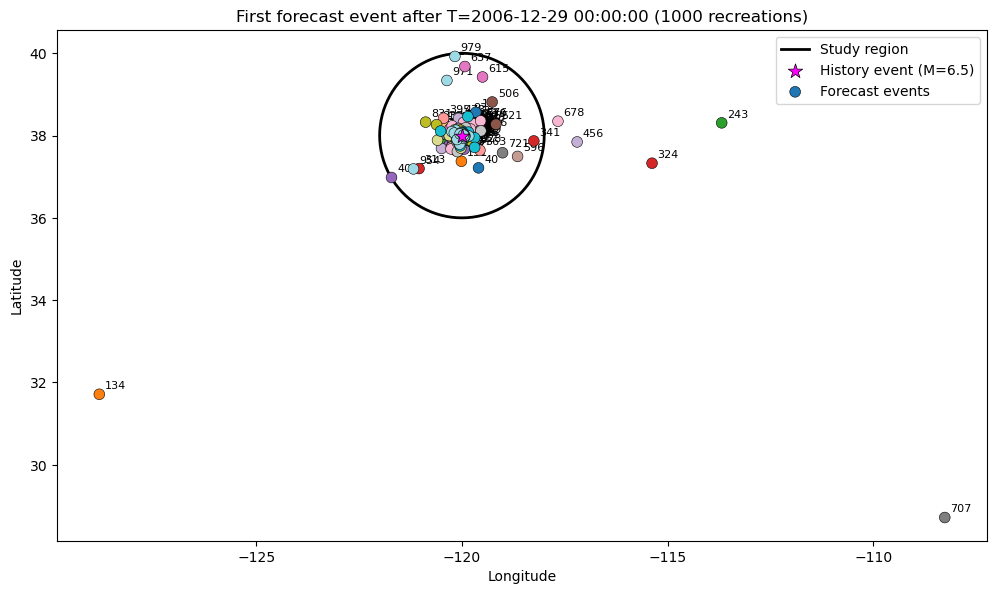

In [13]:
fig_forecast, ax = plt.subplots(figsize=(12, 10))

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

ax.scatter(
    forecast_recreations["longitude"],
    forecast_recreations["latitude"],
    s=60,
    c=forecast_recreations["recreation"],
    cmap="tab20",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    label="Forecast events",
)

for _, row in forecast_recreations.iterrows():
    ax.annotate(
        str(int(row["recreation"])),
        (row["longitude"], row["latitude"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"First forecast event after T={FORECAST_START} ({N_RECREATIONS} recreations)")
ax.set_aspect("equal")
# ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
# ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


Recreations: 1000, first events (event_idx=0): 1000
Time to first event (days): median=0.006, 5-95%=0.000-0.322
2026-06-22 13:34:53,712 - DEBUG - vmin 1.8252919508047797e-06 vmax 14.185414967648532
2026-06-22 13:34:53,712 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02, 1.e+03])
2026-06-22 13:34:53,717 - DEBUG - vmin 1.8252919508047797e-06 vmax 14.185414967648532
2026-06-22 13:34:53,718 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00,

2026-06-22 13:34:54,305 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf', name='Ubuntu', style='italic', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
2026-06-22 13:34:54,305 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/stix/STIXIntegralsUpD-Bold.otf', name='STIXIntegralsUpD', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-22 13:34:54,306 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/liberation/LiberationMono-Italic.ttf', name='Liberation Mono', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-22 13:34:54,307 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/noto/NotoSerifLao-Bold.ttf', name='Noto Serif Lao', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-22 13:34:54,307 - DEBUG - findfont: score(Font

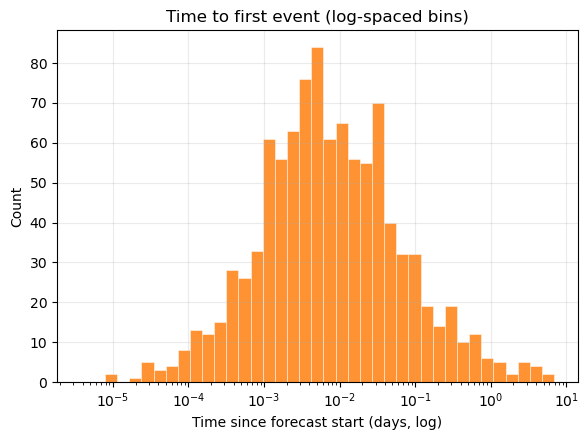

count    1000.000000
mean        0.094529
std         0.441218
min         0.000004
25%         0.001778
50%         0.006429
75%         0.030749
max         6.828349
dtype: float64

In [14]:
# Time to first forecast event — classic ETAS catalog continuation
FIRST_EVENT_IDX = 0
SECONDS_PER_DAY = 86400.0

t0 = pd.to_datetime(FORECAST_START, utc=True)

df_rec = forecast_recreations.loc[
    forecast_recreations["event_idx"] == FIRST_EVENT_IDX
].copy()
df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
df_rec = df_rec.sort_values(["recreation", "time"]).reset_index(drop=True)
df_rec["t_from_start_days"] = (df_rec["time"] - t0).dt.total_seconds() / SECONDS_PER_DAY

dt_to_first = df_rec.loc[df_rec["t_from_start_days"] > 0, "t_from_start_days"].to_numpy()

print(
    f"Recreations: {df_rec['recreation'].nunique()}, "
    f"first events (event_idx={FIRST_EVENT_IDX}): {len(df_rec)}"
)
if np.any(dt_to_first > 0):
    q = np.quantile(dt_to_first, [0.05, 0.5, 0.95])
    print(f"Time to first event (days): median={q[1]:.3f}, 5-95%={q[0]:.3f}-{q[2]:.3f}")

fig_delta_t, ax = plt.subplots(figsize=(6, 4.5))
if len(dt_to_first):
    bins_dt = np.logspace(
        np.log10(dt_to_first.min()),
        np.log10(dt_to_first.max() * 1.01),
        40,
    )
    ax.hist(
        dt_to_first,
        bins=bins_dt,
        color="tab:orange",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_xscale("log")
ax.set_xlabel("Time since forecast start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Time to first event (log-spaced bins)")
ax.grid(True, alpha=0.25)

fig_delta_t.tight_layout()
plt.show()

pd.Series(dt_to_first).describe()


Text(0.5, 1.0, 'CDF of time to first event')

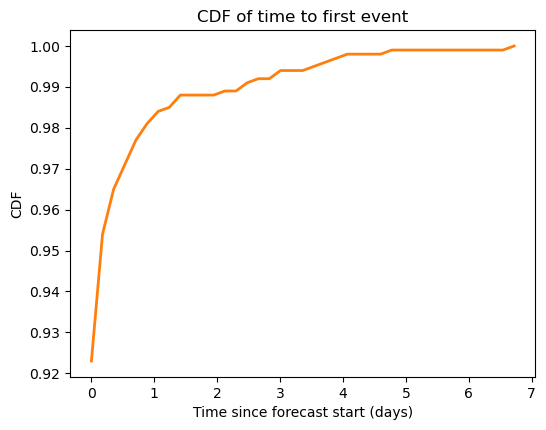

In [15]:
bins_dt = np.linspace(
        dt_to_first.min(),
        dt_to_first.max() * 1.01,
        40,
    )
    
hist, bins = np.histogram(
    dt_to_first,
    bins=bins_dt,
)

# CDF
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

fig_cdf, ax_cdf = plt.subplots(figsize=(6, 4.5))
ax_cdf.plot(bins[:-1], cdf, color="tab:orange", linewidth=2)
ax_cdf.set_xlabel("Time since forecast start (days)")
ax_cdf.set_ylabel("CDF")
ax_cdf.set_title("CDF of time to first event")


### Analytical solution for curcular region

In [16]:
spatial_comp = lambda r, rho, gamma, m_h, m_c, d: 1 / (
    r**2 + d * np.exp(gamma * (m_h - m_c))
) ** rho


def A_h_circ(R, m_h, params):
    return (
        (params["k0"] * np.pi * np.exp(params["a"] * (m_h - params["m_c"])) / params["rho"])
        * (
            spatial_comp(0, params["rho"], params["gamma"], m_h, params["m_c"], params["d"])
            - spatial_comp(R, params["rho"], params["gamma"], m_h, params["m_c"], params["d"])
        )
    )


S = lambda r: np.pi * r**2


def background(t_prime, params):
    return -params["mu"] * S(CIRC_RADIUS) * t_prime


def log_t_next(t_prime, H, params):
    """Log survival when forecast starts at t_h (t = t_h). Uses simple g(t) when USE_SIMPLE_G."""
    t_h = H["t"]
    return log_rhs_region(t_prime + t_h, t_h, H, params)


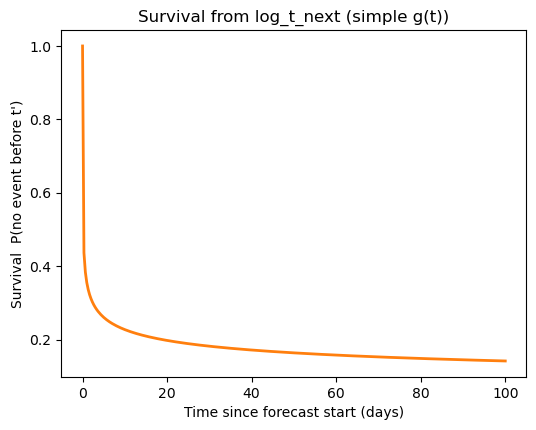

In [17]:
t_prime_rel = np.linspace(0, 100, 300)
t_prime_abs = t_prime_rel + history_dict["t"]

P_no_event = np.exp(log_t_next(t_prime_rel, history_dict, THETA_0))
cdf_analytical_section = 1.0 - P_no_event

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_rel, P_no_event, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("Survival  P(no event before t')")
ax.set_title("Survival from log_t_next (simple g(t))")
plt.show()


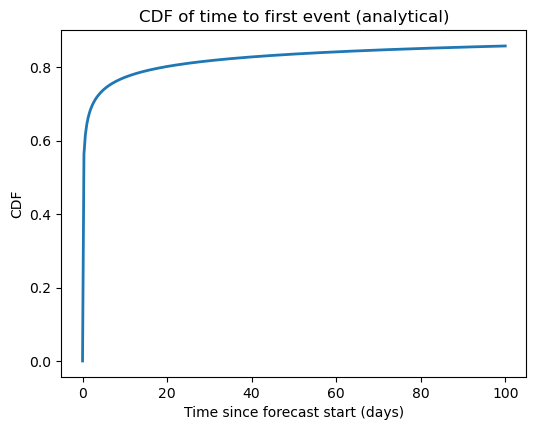

In [18]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_rel, cdf_analytical_section, color="tab:blue", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("CDF")
ax.set_title("CDF of time to first event (analytical)")
plt.show()


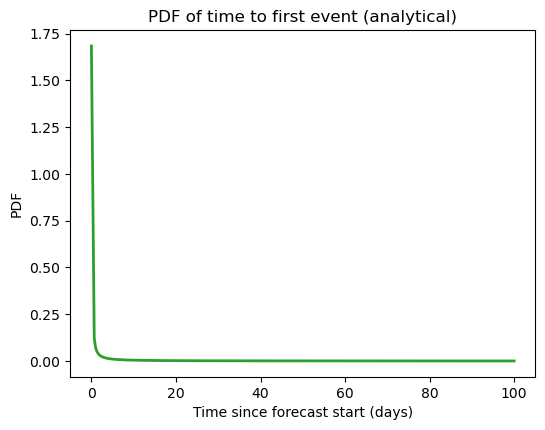

In [19]:
dt_step = t_prime_rel[1] - t_prime_rel[0]
pdf_section = np.clip(np.gradient(cdf_analytical_section, dt_step), 0.0, None)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_rel, pdf_section, color="tab:green", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("PDF")
ax.set_title("PDF of time to first event (analytical)")
plt.show()


# Ogata's modified spatio-temporal thinning method 

In [20]:
from typing import Callable


def ogata_thinning_single_step(
    temporal_intensity: Callable[[float], float],
    t0: float,
    rng: np.random.RandomState,
) -> float:
    """
    Thinning method from Ogata (1981)
    Args:
        temporal_intensity: Callable[[float], float]
            Temporal intensity function. Argument is time.
        t0: float
            current time.
        rng: np.random.RandomState
            Random number generator.
    Returns:
    float: time of the next event.
    """
    # Get upper limit for the temporal intensity
    time = t0 + 0
    current_bound = temporal_intensity(time)
    
    while True:
        tau = rng.exponential(1.0 / current_bound)
        time += tau
        next_intensity = temporal_intensity(time) 
        u = rng.uniform()
        if u < (next_intensity / current_bound):
            return time
        current_bound = next_intensity    
    


In [21]:
def magnitude_generator():
    return mc_b_est.simulate_magnitudes(1, BETA_MAIN, THETA_0['m_c'])[0]


area_km2 = np.pi * CIRC_RADIUS**2
temporal_intensity = lambda t: etas_rate_space_integrated(
    t, area_km2, CIRC_RADIUS, history_dict, THETA_0
)

rngseed = 1905
rng = np.random.RandomState(rngseed)
T = ogata_thinning_single_step(temporal_intensity, history_dict['t'], rng)


In [22]:
def thinning_sample_location(
    spatiotemporal_rate: Callable[[float, float, float], float],
    estimation_t: float,
    rate_at_t: float,
    # rng: np.random.RandomState,
) -> float:
    """
    """
    return lambda x, y: spatiotemporal_rate(x, y, estimation_t) / rate_at_t

spatiotemporal_rate = lambda x, y, t: etas_rate_at_xy(x, y, t, history_dict, THETA_0)

P_x_y = thinning_sample_location(spatiotemporal_rate, T, temporal_intensity(T))


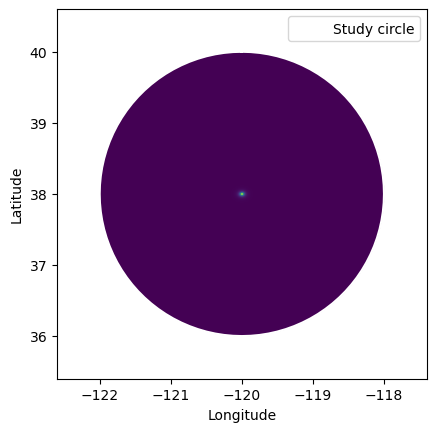

Integral of P_x_y over the circle: 0.0003960543939495301


In [23]:
width_factor = 1.3
n_pix = 1000

# 1. Meshgrid (X=lon, Y=lat)
X, Y = np.meshgrid(
    np.linspace(
        history_dict["x"] - width_factor * CIRC_RADIUS,
        history_dict["x"] + width_factor * CIRC_RADIUS,
        n_pix,
    ),
    np.linspace(
        history_dict["y"] - width_factor * CIRC_RADIUS,
        history_dict["y"] + width_factor * CIRC_RADIUS,
        n_pix,
    ),
)
P_x_y_values = P_x_y(X, Y)

# Keep pixels only inside the circular study region
inside_circle = np.fromiter(
    (circle.contains(Point(lat, lon)) for lat, lon in zip(Y.ravel(), X.ravel())),
    dtype=bool,
    count=Y.size,
).reshape(Y.shape)
P_x_y_values = np.where(inside_circle, P_x_y_values, np.nan)

# 2. Plot extent
extent = [
    history_dict["x"] - width_factor * CIRC_RADIUS,
    history_dict["x"] + width_factor * CIRC_RADIUS,
    history_dict["y"] - width_factor * CIRC_RADIUS,
    history_dict["y"] + width_factor * CIRC_RADIUS,
]
fig, ax = plt.subplots()
ax.imshow(P_x_y_values, extent=extent, origin="lower", cmap="viridis")
circ_lats, circ_lons = circle.exterior.xy
ax.plot(circ_lons, circ_lats, color="white", linewidth=1.5, label="Study circle")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
# plt.colorbar()
ax.legend(loc="upper right")
plt.show()

# 3. Integrate only over in-circle pixels
dx = (2 * width_factor * CIRC_RADIUS) / (n_pix - 1)
dy = (2 * width_factor * CIRC_RADIUS) / (n_pix - 1)
P_x_y_integral = np.nansum(P_x_y_values) * dx * dy

print(f"Integral of P_x_y over the circle: {P_x_y_integral}")


In [24]:
times_thinning = []
rngseed = 1905
for i in range(N_RECREATIONS):
    rng = np.random.RandomState(rngseed)
    T = ogata_thinning_single_step(temporal_intensity, history_dict['t'], rng)
    times_thinning.append(T)
    rngseed += 1



2026-06-22 13:35:10,766 - DEBUG - vmin 0.709540362282587 vmax 1347.3511174537743
2026-06-22 13:35:10,767 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
2026-06-22 13:35:10,770 - DEBUG - vmin 0.709540362282587 vmax 1347.3511174537743
2026-06-22 13:35:10,771 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
2026-06-22 13:35:10,771 - DEBUG - vmin 0.709540362282587 vmax 1347.3511174537743
2026-06-22 13:35:10,772 - DEBU

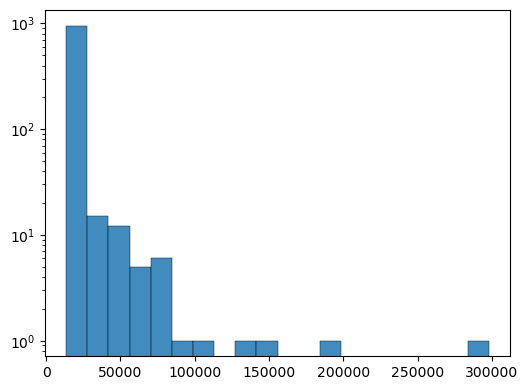

In [25]:
f, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(times_thinning, bins=20, edgecolor="black", linewidth=0.35, alpha=0.85)
ax.set_yscale("log")
plt.show()


# Compare three first-event forecasts (simple g(t))

All three approaches target

\[
F(\Delta t) = P(\text{first event in the circular domain by } T_h + \Delta t)
\]

where \(T_h\) is `history_event_time`.

| Method | Implementation | Temporal kernel |
|--------|----------------|-----------------|
| **A. Analytical** | `1 - exp(log_rhs_region)` | Simple \(g(t)=(t-t_h+c)^{-(1+\omega)}\) (no \(\tau\) decay) |
| **B. Classic ETAS** | `simulate_catalog_continuation` | Full ETAS kernel (includes \(\tau\) decay) |
| **C. Ogata thinning** | `ogata_thinning_single_step` on space-integrated rate | Same simple \(g(t)\) as A |

A and C use `USE_SIMPLE_G = True` so the theoretical curve and thinning share the same simplified temporal model. Classic ETAS (B) still runs the production simulator with full parameters — expect some mismatch versus A/C.


2026-06-22 13:35:10,898 - DEBUG - vmin 0.0001 vmax 486.80455044820405
2026-06-22 13:35:10,898 - DEBUG - ticklocs array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02,
       1.e+03, 1.e+04])
2026-06-22 13:35:10,902 - DEBUG - vmin 0.0001 vmax 486.80455044820405
2026-06-22 13:35:10,903 - DEBUG - ticklocs array([2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6

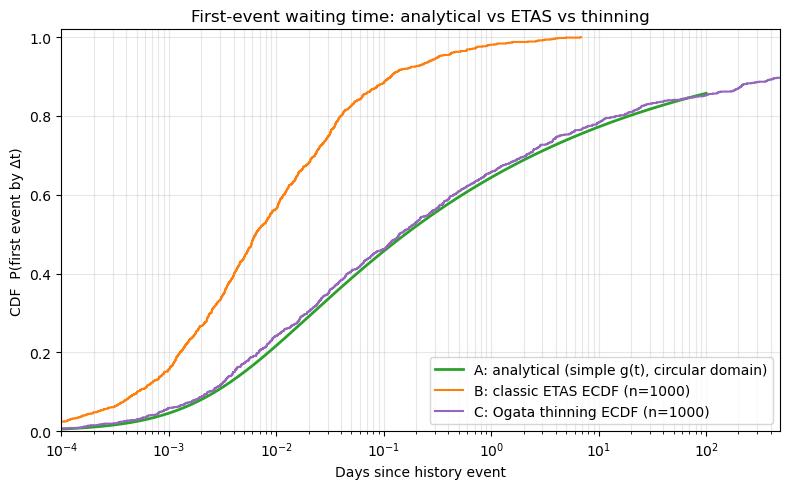

,method,n,median_days,p05_days,p95_days
0,A: analytical (simple g),400,0.159121,0.001116,NaN
1,B: classic ETAS,1000,0.006429,0.000220,0.322347
2,C: Ogata thinning,1000,0.140300,0.000878,7194.848283


In [26]:
def _ecdf_positive(samples):
    x = np.sort(np.asarray(samples, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return np.array([]), np.array([])
    return x, np.arange(1, x.size + 1, dtype=float) / x.size


def _analytical_median_dt(delta_t, cdf):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= 0.5):
        return np.nan
    return float(np.interp(0.5, cdf, delta_t))


def _analytical_quantile_dt(delta_t, cdf, q):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= q):
        return np.nan
    return float(np.interp(q, cdf, delta_t))


def _quantile_row(name, x):
    x = np.asarray(x, dtype=float)
    x = x[(x > 0) & np.isfinite(x)]
    if x.size == 0:
        return {"method": name, "n": 0}
    q = np.quantile(x, [0.05, 0.5, 0.95])
    return {
        "method": name,
        "n": int(x.size),
        "median_days": float(q[1]),
        "p05_days": float(q[0]),
        "p95_days": float(q[2]),
    }


history_t_days = float(history_dict["t"])

delta_t_analytical = np.geomspace(1e-5, 100.0, 400)
t_eval = delta_t_analytical + history_t_days

log_survival = log_rhs_region(t_eval, history_t_days, history_dict, THETA_0)
cdf_analytical = 1.0 - np.clip(np.exp(log_survival), 0.0, 1.0)

if "dt_to_first" not in globals():
    t0 = pd.to_datetime(FORECAST_START, utc=True)
    df_rec = forecast_recreations.loc[forecast_recreations["event_idx"] == 0].copy()
    df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
    dt_to_first = (
        df_rec.loc[df_rec["time"] > t0, "time"] - t0
    ).dt.total_seconds().to_numpy() / 86400.0
x_etas, y_etas = _ecdf_positive(dt_to_first)

delta_t_thinning = np.asarray(times_thinning, dtype=float) - history_t_days
x_thinning, y_thinning = _ecdf_positive(delta_t_thinning)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    delta_t_analytical,
    cdf_analytical,
    color="tab:green",
    linewidth=2,
    label="A: analytical (simple g(t), circular domain)",
)
if x_etas.size:
    ax.step(
        x_etas,
        y_etas,
        where="post",
        color="tab:orange",
        linewidth=1.5,
        label=f"B: classic ETAS ECDF (n={x_etas.size})",
    )
if x_thinning.size:
    ax.step(
        x_thinning,
        y_thinning,
        where="post",
        color="tab:purple",
        linewidth=1.5,
        label=f"C: Ogata thinning ECDF (n={x_thinning.size})",
    )

ax.set_xscale("log")
# Hardcoded to match single_point_history_circular_domain.ipynb (comparison cell).
FIRST_EVENT_WAITING_TIME_XLIM = (1e-4, 486.80455044820405)
ax.set_xlim(*FIRST_EVENT_WAITING_TIME_XLIM)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Days since history event")
ax.set_ylabel("CDF  P(first event by Δt)")
ax.set_title("First-event waiting time: analytical vs ETAS vs thinning")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

summary = pd.DataFrame(
    [
        {
            "method": "A: analytical (simple g)",
            "n": int(delta_t_analytical.size),
            "median_days": _analytical_median_dt(delta_t_analytical, cdf_analytical),
            "p05_days": _analytical_quantile_dt(delta_t_analytical, cdf_analytical, 0.05),
            "p95_days": _analytical_quantile_dt(delta_t_analytical, cdf_analytical, 0.95),
        },
        _quantile_row("B: classic ETAS", dt_to_first),
        _quantile_row("C: Ogata thinning", delta_t_thinning),
    ]
)
summary


### PDF check: histograms vs analytical \(dF/d\Delta t\)

Normalized histograms of \(\Delta t\) from classic ETAS and Ogata thinning should bracket the analytical PDF from differentiating the simple-\(g(t)\) CDF (method A).


2026-06-22 13:35:11,171 - DEBUG - vmin 1.8771860995370372e-06 vmax 71716.64268439278
2026-06-22 13:35:11,172 - DEBUG - ticklocs array([1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06,
       1.e+08])
2026-06-22 13:35:11,175 - DEBUG - vmin 1.8771860995370372e-06 vmax 71716.64268439278
2026-06-22 13:35:11,176 - DEBUG - ticklocs array([], dtype=float64)
2026-06-22 13:35:11,176 - DEBUG - vmin 1.8771860995370372e-06 vmax 71716.64268439278
2026-06-22 13:35:11,177 - DEBUG - ticklocs array([1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06,
       1.e+08])
2026-06-22 13:35:11,177 - DEBUG - vmin 1.8771860995370372e-06 vmax 71716.64268439278
2026-06-22 13:35:11,178 - DEBUG - ticklocs array([1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06,
       1.e+08])
2026-06-22 13:35:11,178 - DEBUG - vmin 1.8771860995370372e-06 vmax 71716.64268439278
2026-06-22 13:35:11,178 - DEBUG - ticklocs array([], dtype=float64)
2026-06-22 13:35:11,179 - DEBUG - vmin 1.87718609

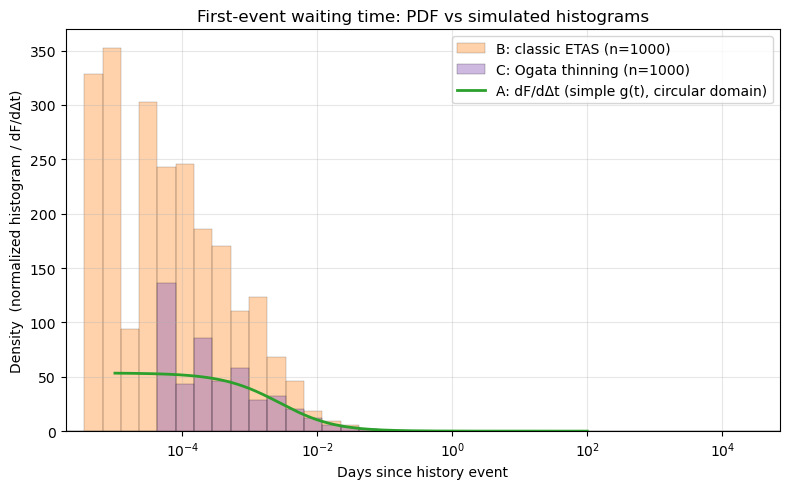

In [27]:
pdf_analytical = np.clip(np.gradient(cdf_analytical, delta_t_analytical), 0.0, None)

samples_for_bins = []
if "dt_to_first" in globals():
    samples_for_bins.append(np.asarray(dt_to_first, dtype=float))
if "delta_t_thinning" in globals():
    samples_for_bins.append(np.asarray(delta_t_thinning, dtype=float))
positive_all = np.concatenate(
    [x[(x > 0) & np.isfinite(x)] for x in samples_for_bins if x.size]
) if samples_for_bins else np.array([])
if positive_all.size == 0:
    raise ValueError("Run catalog continuation and/or thinning first.")

xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
xmax = max(xmin * 10, float(np.percentile(positive_all, 99.5)) * 1.1)
hist_bins = np.geomspace(xmin, xmax, 40)

fig, ax = plt.subplots(figsize=(8, 5))

dt_pos = dt_to_first[(dt_to_first > 0) & np.isfinite(dt_to_first)]
if dt_pos.size:
    ax.hist(
        dt_pos,
        bins=hist_bins,
        density=True,
        alpha=0.35,
        color="tab:orange",
        edgecolor="black",
        linewidth=0.35,
        label=f"B: classic ETAS (n={dt_pos.size})",
    )

thin_pos = delta_t_thinning[(delta_t_thinning > 0) & np.isfinite(delta_t_thinning)]
if thin_pos.size:
    ax.hist(
        thin_pos,
        bins=hist_bins,
        density=True,
        alpha=0.45,
        color="tab:purple",
        edgecolor="black",
        linewidth=0.35,
        label=f"C: Ogata thinning (n={thin_pos.size})",
    )

mask_pdf = (delta_t_analytical >= xmin) & (delta_t_analytical <= xmax) & np.isfinite(pdf_analytical)
ax.plot(
    delta_t_analytical[mask_pdf],
    pdf_analytical[mask_pdf],
    color="tab:green",
    linewidth=2.0,
    label="A: dF/dΔt (simple g(t), circular domain)",
)

ax.set_xscale("log")
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Days since history event")
ax.set_ylabel("Density  (normalized histogram / dF/dΔt)")
ax.set_title("First-event waiting time: PDF vs simulated histograms")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()
